In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [118]:
# Load the classic airline passengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
ts = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
ts.columns = ['passengers']
ts.index.freq = 'MS'  # Monthly Start frequency

print(ts.shape)
ts.head()

(144, 1)


,passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


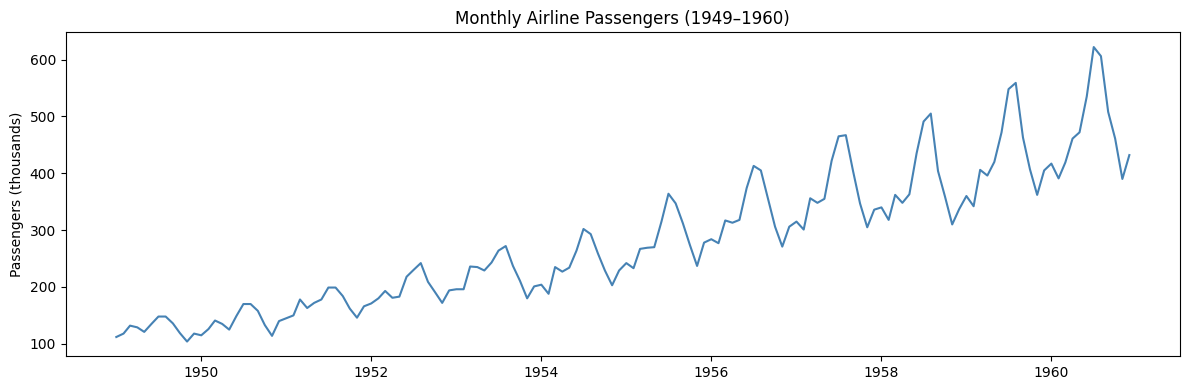

In [119]:
plt.figure(figsize=(12, 4))
plt.plot(ts, color='steelblue')
plt.title('Monthly Airline Passengers (1949–1960)')
plt.ylabel('Passengers (thousands)')
plt.tight_layout()
plt.show()

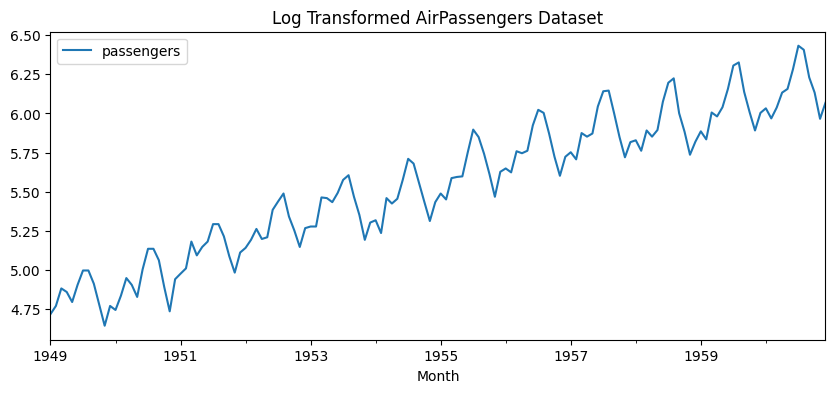

In [120]:
ts_log = np.log(ts)
ts_log.plot(title="Log Transformed AirPassengers Dataset", figsize=(10,4))
plt.show()

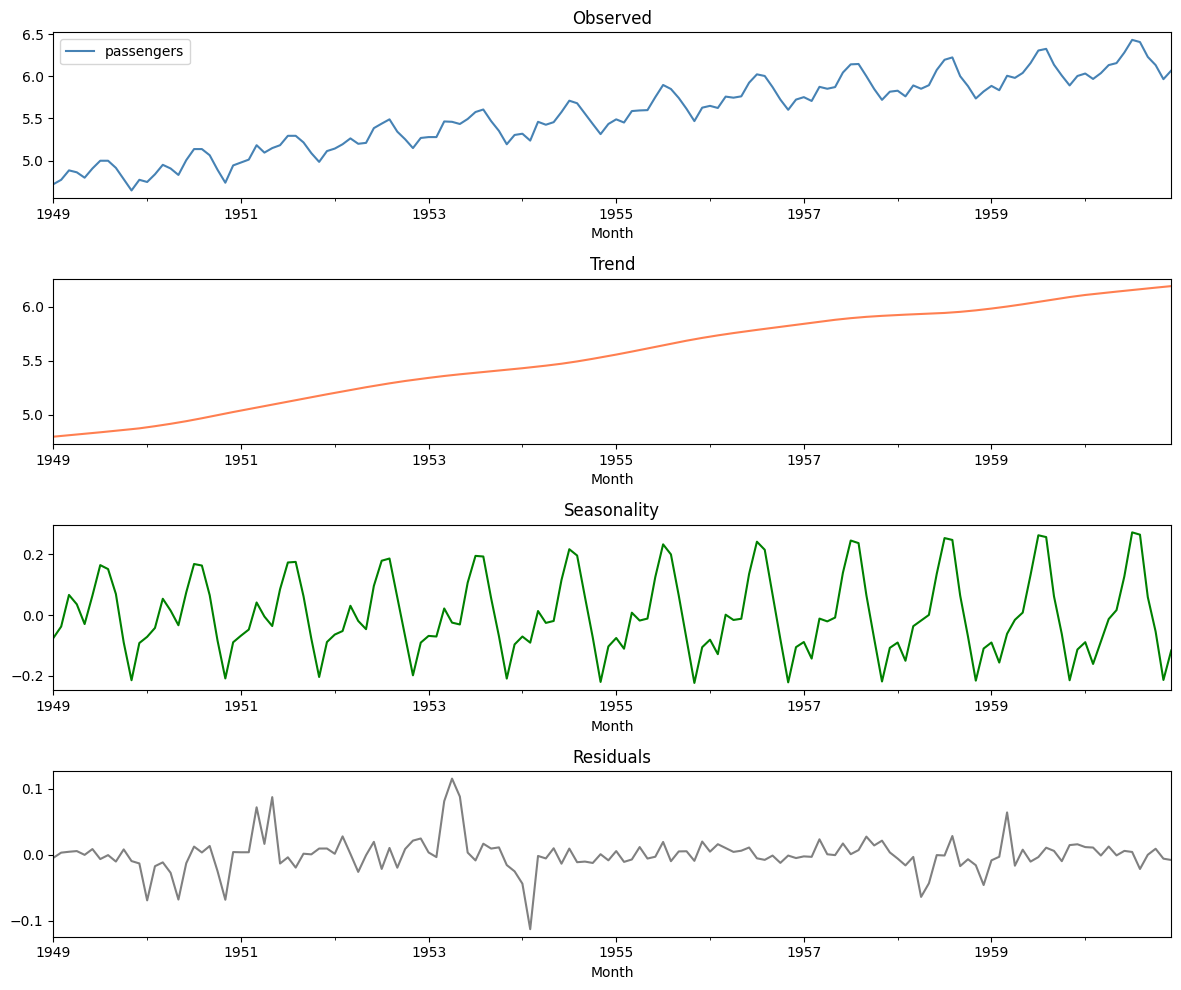

In [140]:
decomp = STL(ts_log, period=12, robust=True).fit()


fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomp.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Trend', color='coral')
decomp.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomp.resid.plot(ax=axes[3], title='Residuals', color='gray')
plt.tight_layout()
plt.show()

In [122]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

def kpss_test(series):
    result = kpss(series)
    print("KPSS Statistic:", result[0])
    print("p-value:", result[1])

print("ADF Test:")
adf_test(ts)

print("\nKPSS Test:")
kpss_test(ts)

ADF Test:
ADF Statistic: 0.8153688792060463
p-value: 0.991880243437641

KPSS Test:
KPSS Statistic: 1.6513122354165206
p-value: 0.01


C:\Users\E15\AppData\Local\Temp\ipykernel_14520\3864636452.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series)


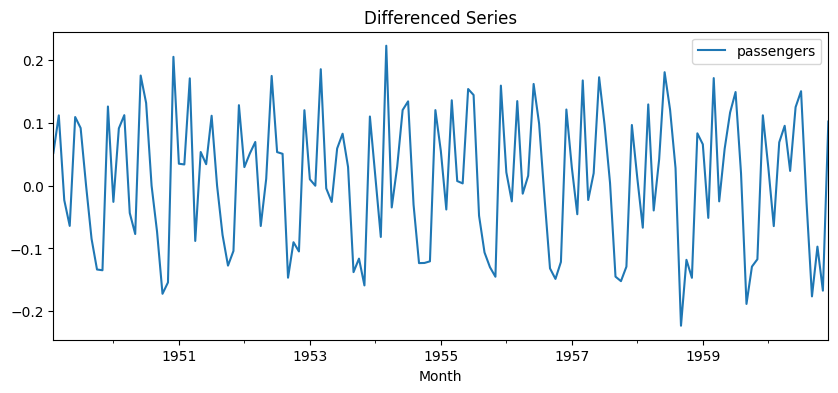

After Differencing:
ADF Statistic: -2.717130598388136
p-value: 0.0711205481508582

KPSS Test:
KPSS Statistic: 0.03830446954674065
p-value: 0.1


C:\Users\E15\AppData\Local\Temp\ipykernel_14520\3864636452.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series)


In [123]:
ts_diff = ts_log.diff().dropna()

ts_diff.plot(title="Differenced Series", figsize=(10,4))
plt.show()

print("After Differencing:")
adf_test(ts_diff)
print("\nKPSS Test:")
kpss_test(ts_diff)

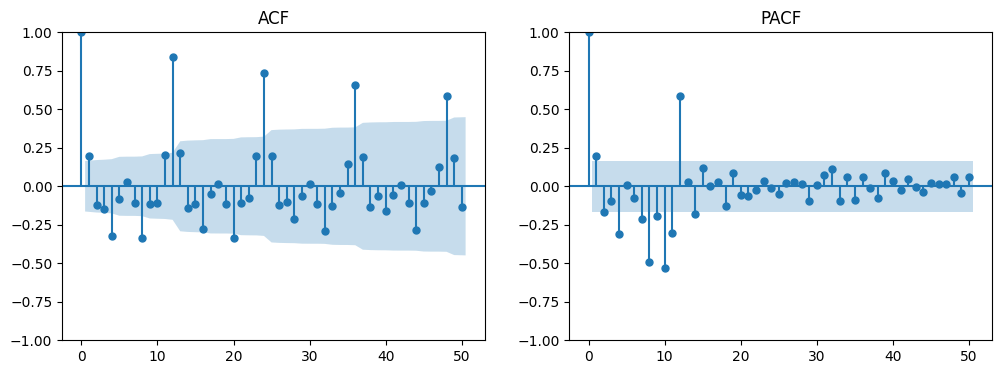

In [124]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(ts_diff,lags = 50, ax=ax[0])
plot_pacf(ts_diff,lags = 50, ax=ax[1])

ax[0].set_title("ACF")
ax[1].set_title("PACF")

plt.show()

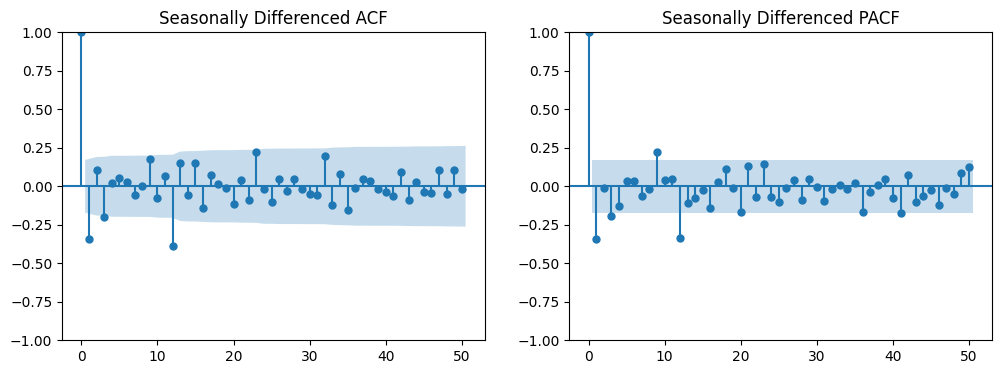

After Differencing:
ADF Statistic: -4.443324941831113
p-value: 0.00024859123113841515

KPSS Test:
KPSS Statistic: 0.0731909698312545
p-value: 0.1


C:\Users\E15\AppData\Local\Temp\ipykernel_14520\3864636452.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series)


In [141]:
ts_diff_seasonal = ts_diff.diff(12).dropna()
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(ts_diff_seasonal,lags = 50, ax=ax[0])
plot_pacf(ts_diff_seasonal,lags = 50, ax=ax[1])
ax[0].set_title("Seasonally Differenced ACF")
ax[1].set_title("Seasonally Differenced PACF")
plt.show()
print("After Differencing:")
adf_test(ts_diff_seasonal)
print("\nKPSS Test:")
kpss_test(ts_diff_seasonal)

In [126]:
model = SARIMAX(ts_log, order=(1,1,1))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  144
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 124.313
Date:                Mon, 27 Apr 2026   AIC                           -242.626
Time:                        20:40:31   BIC                           -233.738
Sample:                    01-01-1949   HQIC                          -239.014
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5773      0.164     -3.516      0.000      -0.899      -0.256
ma.L1          0.8478      0.098      8.686      0.000       0.656       1.039
sigma2         0.0103      0.002      5.992      0.0

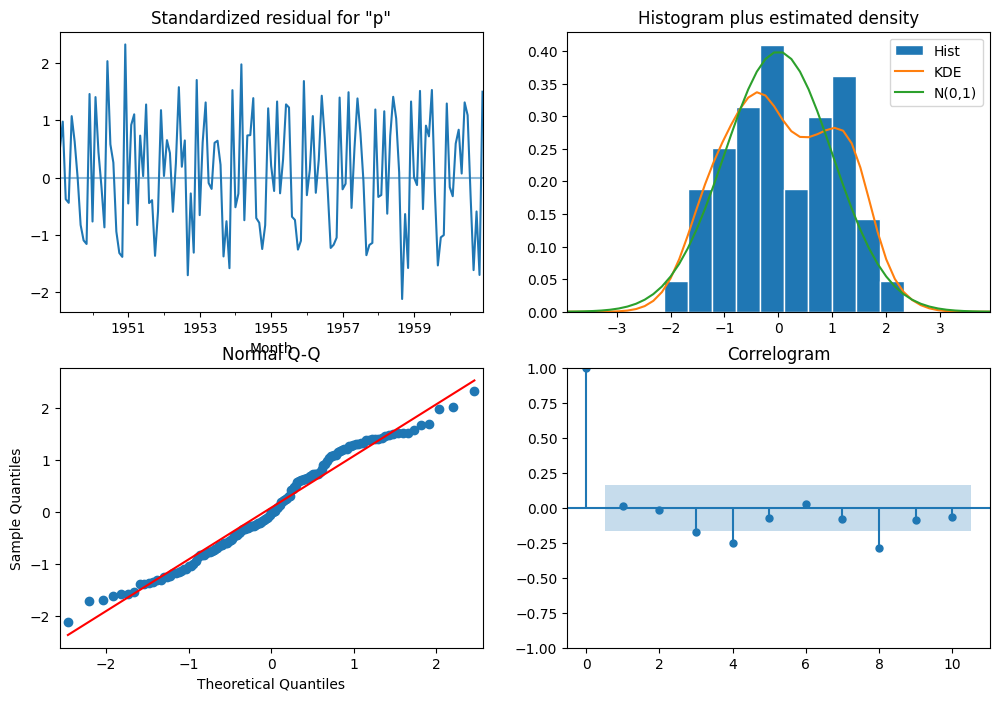

In [127]:
results.plot_diagnostics(figsize=(12,8))
plt.show()

In [ ]:
res = []
for p in range(2):
    for q in range(2):
         for P in range(2):
             for Q in range(2): 
                sarima_models = SARIMAX(
                 ts_log,
                 order=(p, 1, q),
                 seasonal_order=(P, 1, Q, 12)
                 )
                sarima_resultss = sarima_models.fit()
                res.append((p, q, P, Q, sarima_resultss.aic, sarima_resultss.bic))
                print(f"Seasonal Order: (p,d,q)(P,D,Q) = ({p},1,{q})({P},1,{Q})")
                print(sarima_resultss.aic, sarima_resultss.bic)
                sarima_resultss = sarima_models.fit()
                res.append((p, q, P, Q, sarima_resultss.aic, sarima_resultss.bic))
                print(f"Seasonal Order: (p,d,q)(P,D,Q) = ({p},1,{q})({P},1,{Q})")
                print(sarima_resultss.aic, sarima_resultss.bic)
                print("\n")
res_df = pd.DataFrame(res, columns=['p', 'q', 'P', 'Q', 'AIC', 'BIC'])
print(res_df.sort_values(by='AIC').head())

Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(0,1,0)
-434.8299666896354 -431.9547693664342
Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(0,1,0)
-434.8299666896354 -431.9547693664342


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(0,1,1)
-467.5526697049577 -461.8022750585554
Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(0,1,1)
-467.5526697049577 -461.8022750585554


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(0,1,2)
-465.559346923836 -456.93375495423254
Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(0,1,2)
-465.559346923836 -456.93375495423254


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(1,1,0)
-457.01470363924324 -451.26430899284094
Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(1,1,0)
-457.01470363924324 -451.26430899284094


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(1,1,1)
-465.55846266116953 -456.93287069156605
Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(1,1,1)
-465.55846266116953 -456.93287069156605


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,0)(1,1,2)
-463.581942257568 -452.0811529647634
Seasonal Order: (p,d,q)(P,D,Q) = (0,1

c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,2)(2,1,1)
-478.1261626205156 -460.8749786813087


c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,2)(2,1,1)
-478.1261626205156 -460.8749786813087


Seasonal Order: (p,d,q)(P,D,Q) = (0,1,2)(2,1,2)
-476.098599383467 -455.9722181210589
Seasonal Order: (p,d,q)(P,D,Q) = (0,1,2)(2,1,2)
-476.098599383467 -455.9722181210589


Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(0,1,0)
-449.01320959630175 -443.26281494989945
Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(0,1,0)
-449.01320959630175 -443.26281494989945


Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(0,1,1)
-481.4838165152302 -472.85822454562674
Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(0,1,1)
-481.4838165152302 -472.85822454562674


Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(0,1,2)
-479.73911403319704 -468.23832474039244
Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(0,1,2)
-479.73911403319704 -468.23832474039244


Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(1,1,0)
-474.81275056390876 -466.1871585943053
Seasonal Order: (p,d,q)(P,D,Q) = (1,1,0)(1,1,0)
-474.81275056390876 -466.1871585943053


Seasonal Order: (p,d,q)(P,D,Q) =

...

Seasonal Order: (p,d,q)(P,D,Q) = (2,1,2)(1,1,2)
-475.73448330458626 -452.73290471897707


Seasonal Order: (p,d,q)(P,D,Q) = (2,1,2)(2,1,0)
-474.5784380292509 -454.4520567668428
Seasonal Order: (p,d,q)(P,D,Q) = (2,1,2)(2,1,0)
-474.5784380292509 -454.4520567668428




c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Seasonal Order: (p,d,q)(P,D,Q) = (2,1,2)(2,1,1)
-475.6312753685605 -452.6296967829513


c:\Users\E15\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Seasonal Order: (p,d,q)(P,D,Q) = (2,1,2)(2,1,1)
-475.6312753685605 -452.6296967829513


Seasonal Order: (p,d,q)(P,D,Q) = (2,1,2)(2,1,2)
-473.7129528908051 -447.83617698199475
Seasonal Order: (p,d,q)(P,D,Q) = (2,1,2)(2,1,2)
-473.7129528908051 -447.83617698199475


     p  q  P  Q         AIC         BIC
20   0  1  0  1 -483.392960 -474.767368
21   0  1  0  1 -483.392960 -474.767368
129  2  1  0  1 -482.085766 -467.709780
128  2  1  0  1 -482.085766 -467.709780
22   0  1  0  2 -481.955576 -470.454787


In [148]:
sarima_model = SARIMAX(ts_log,
                      order=(0,1,1),
                      seasonal_order=(0,1,1,12))

sarima_results = sarima_model.fit()

print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 244.696
Date:                            Mon, 27 Apr 2026   AIC                           -483.393
Time:                                    20:54:13   BIC                           -474.767
Sample:                                01-01-1949   HQIC                          -479.888
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4019      0.073     -5.506      0.000      -0.545      -0.259
ma.S.L12      -0.5571      0.096   

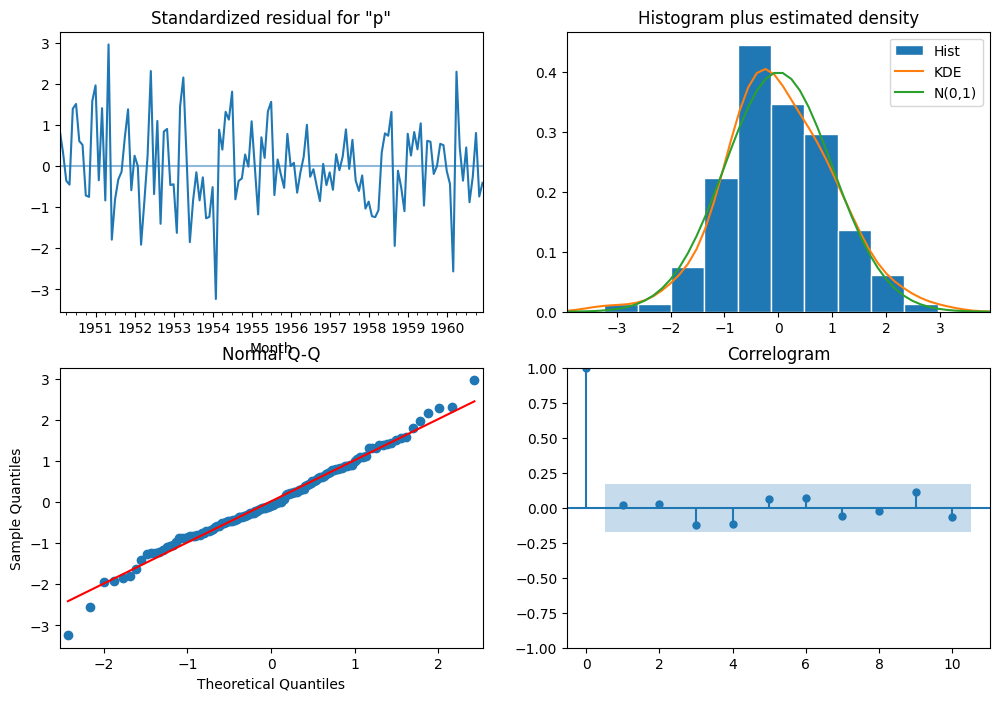

In [149]:
sarima_results.plot_diagnostics(figsize=(12,8))
plt.show()

In [154]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 115
Test size: 29


In [155]:
model = SARIMAX(np.log(train),
                order=(0,1,1),
                seasonal_order=(0,1,1,12))

results = model.fit()

In [156]:
forecast = results.get_forecast(steps=len(test))

pred_mean = np.exp(forecast.predicted_mean)
conf_int = np.exp(forecast.conf_int())

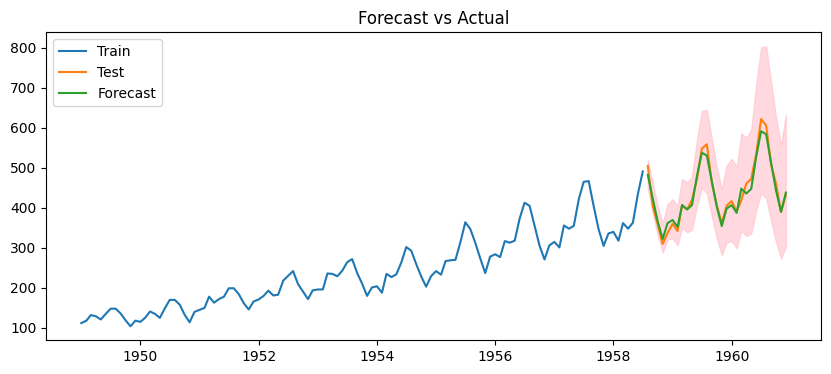

In [158]:
plt.figure(figsize=(10,4))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(pred_mean, label="Forecast")

plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.6)

plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [159]:
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12.605443310075195
RMSE: 15.683161729312594
